# Model 3 — Consumption Pricing + Uncertainty
**Part 3 of 4 in *Consumption Pricing Models for Enterprise Infrastructure***

> **A note on inputs and provenance:** All inputs are illustrative, drawn from publicly available industry benchmarks. No proprietary or confidential data is used. The insurance Monte Carlo in particular is a clean-room rebuild from public actuarial methodology — not the production model from any prior role. See the README for full context.

## What this model does

The TCO model in Model 2 runs once on point estimates. Real decisions face uncertain inputs — demand might come in 12% below forecast, prices might shift, burst usage varies. This model wraps the deterministic pricing calculator in a Monte Carlo layer (20,000 iterations across stochastic growth and price), then runs sensitivity analysis to identify which input drives variance the most.

The headline finding: **demand growth uncertainty drives roughly 3× more variance in long-term savings than price negotiation does.** Better forecasting beats harder negotiating.

See `02_staas_tco.ipynb` for the deterministic baseline this model wraps.


## Setup — Imports & Shared Utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import rankdata
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
PURPLE = '#7C3AED'
TEAL   = '#0891B2'
GRAY   = '#6B7280'

def fmt_k(n):
    """Format a number as a compact dollar string."""
    if abs(n) >= 1_000_000:
        return f'${n/1_000_000:.1f}M'
    if abs(n) >= 1_000:
        return f'${n/1_000:.0f}K'
    return f'${n:.0f}'

print('Setup complete.')

Setup complete.


### Two components

**Part A — Deterministic pricing calculator**  
Computes exact monthly/annual costs at committed + burst rates. 

**Part B — Monte Carlo uncertainty layer**  
> *"With 80% confidence, you save between $X and $Y over 3 years."*

This is more defensible than `$500K savings` on a slide.

### The regression connection
 **regression** sits underneath the deterministic calculator:  
- Dependent variable: deal close probability OR realized signed price  
- Independent variables: committed TB, customer segment, contract length, competitor in deal, geography  
- Output: coefficients that tell you which factors predict price sensitivity  
- Use: set tiered pricing by segment, identify discount thresholds that don't hurt close rate  

**Why regression falls short here → use gradient boosting instead:**
- Linearity: price sensitivity is non-linear (customers elastic at some thresholds, inelastic at others)
- Multicollinearity: deal size and segment are correlated → unstable coefficients
- Selection bias: you only observe closed deals — no data on prices that lost
- XGBoost handles all three automatically

### The tornado chart takeaway
The sensitivity chart shows that **growth rate uncertainty dominates price uncertainty** in driving savings outcomes. 
---

### Part A — Deterministic Pricing

In [8]:
# ── Model 3 Assumptions ────────────────────────────────────────────────
COMMITTED_TB  = 500     # TB committed in contract
KS_RATE       = 35      # $/TB/mo committed rate
BURST_PCT3    = 0.15    # Expected burst as % of committed
BURST_PREM3   = 0.40    # Burst premium over committed rate
CONTRACT_YRS  = 3

# On-prem benchmark (for savings comparison)
OP_HW_PHYS    = 3_500   # $/TB physical hardware
OP_LP_YR      = 230     # $/TB physical/yr labor + power
OVERPROV3     = 0.30
DATA_RED3     = 3.0

# Monte Carlo parameters
N3            = 20_000
GROWTH_MEAN   = 0.20
GROWTH_STD    = 0.08    # Forecast uncertainty: ±1 std = 12%-28% growth
PRICE_MEAN    = KS_RATE
PRICE_STD     = 3.0     # Price volatility over contract term

# Deterministic monthly breakdown
burst_tb  = COMMITTED_TB * BURST_PCT3
comm_mo   = COMMITTED_TB * KS_RATE
burst_mo  = burst_tb * KS_RATE * (1 + BURST_PREM3)
total_mo  = comm_mo + burst_mo
blended   = total_mo / (COMMITTED_TB + burst_tb)

print('=== Monthly Pricing Breakdown ===')
print(f'Committed capacity ({COMMITTED_TB} TB × ${KS_RATE}/mo):  {fmt_k(comm_mo)}')
print(f'Burst usage ({burst_tb:.0f} TB at +{BURST_PREM3*100:.0f}% premium):  {fmt_k(burst_mo)}')
print(f'Total monthly:                        {fmt_k(total_mo)}')
print(f'Annual total:                         {fmt_k(total_mo * 12)}')
print(f'Blended rate:                         ${blended:.2f}/TB/mo')
print(f'Committed rate:                       ${KS_RATE}/TB/mo')
print(f'Premium from burst:                   ${blended - KS_RATE:.2f}/TB/mo blended lift')

=== Monthly Pricing Breakdown ===
Committed capacity (500 TB × $35/mo):  $18K
Burst usage (75 TB at +40% premium):  $4K
Total monthly:                        $21K
Annual total:                         $254K
Blended rate:                         $36.83/TB/mo
Committed rate:                       $35/TB/mo
Premium from burst:                   $1.83/TB/mo blended lift


### Part B — Monte Carlo (Demand + Price Uncertainty)

In [9]:
ks_3yr = np.zeros(N3)
op_3yr = np.zeros(N3)

for i in range(N3):
    g     = max(0.0, np.random.normal(GROWTH_MEAN, GROWTH_STD))
    price = max(5.0, np.random.normal(PRICE_MEAN,  PRICE_STD))
    ks = op = 0.0
    cap = COMMITTED_TB

    for yr in range(1, CONTRACT_YRS + 1):
        cap  *= (1 + g)
        burst = cap * BURST_PCT3
        ks   += (cap * price + burst * price * (1 + BURST_PREM3)) * 12

        # On-prem: buys for 3-year peak upfront, amortized
        p_log  = COMMITTED_TB * (1 + g) ** CONTRACT_YRS * (1 + OVERPROV3)
        p_phys = p_log / DATA_RED3
        op    += p_phys * OP_HW_PHYS / CONTRACT_YRS + p_phys * OP_LP_YR

    ks_3yr[i] = ks / 1_000
    op_3yr[i] = op / 1_000

savings = op_3yr - ks_3yr

p10_ks = np.percentile(ks_3yr, 10)
p50_ks = np.percentile(ks_3yr, 50)
p90_ks = np.percentile(ks_3yr, 90)
p10_sv = np.percentile(savings, 10)
p50_sv = np.percentile(savings, 50)
p90_sv = np.percentile(savings, 90)
prob   = (savings > 0).mean() * 100

print('=== 3-Year Monte Carlo Results ===')
print(f'STaaS cost  P10: {fmt_k(p10_ks*1000)}  P50: {fmt_k(p50_ks*1000)}  P90: {fmt_k(p90_ks*1000)}')
print(f'Savings vs OP  P10: {fmt_k(p10_sv*1000)}  P50: {fmt_k(p50_sv*1000)}  P90: {fmt_k(p90_sv*1000)}')
print(f'Uncertainty band (P90-P10): {fmt_k((p90_sv-p10_sv)*1000)}')
print(f'STaaS wins in {prob:.0f}% of simulated scenarios')
print(f'\nCustomer pitch: "With 80% confidence, you save between {fmt_k(p10_sv*1000)} and {fmt_k(p90_sv*1000)} over 3 years."')

=== 3-Year Monte Carlo Results ===
STaaS cost  P10: $886K  P50: $1.1M  P90: $1.4M
Savings vs OP  P10: $245K  P50: $456K  P90: $717K
Uncertainty band (P90-P10): $472K
STaaS wins in 100% of simulated scenarios

Customer pitch: "With 80% confidence, you save between $245K and $717K over 3 years."


### Sensitivity Analysis

In [10]:
def scenario_savings(g_val=None, p_val=None, bp_val=None, n=2_500):
    """Run mini Monte Carlo with one input fixed to measure its impact on savings."""
    out = np.zeros(n)
    for i in range(n):
        g  = g_val  if g_val  is not None else max(0, np.random.normal(GROWTH_MEAN, GROWTH_STD))
        pr = p_val  if p_val  is not None else max(5, np.random.normal(PRICE_MEAN,  PRICE_STD))
        bp = bp_val if bp_val is not None else BURST_PCT3
        ks = op = 0.0
        cap = COMMITTED_TB
        for yr in range(1, CONTRACT_YRS + 1):
            cap *= (1 + g)
            ks  += (cap * pr + cap * bp * pr * (1 + BURST_PREM3)) * 12
            p_log  = COMMITTED_TB * (1 + g) ** CONTRACT_YRS * (1 + OVERPROV3)
            p_phys = p_log / DATA_RED3
            op     += p_phys * OP_HW_PHYS / CONTRACT_YRS + p_phys * OP_LP_YR
        out[i] = (op - ks) / 1_000
    return float(np.median(out))

sens = [
    ('Demand growth rate',
     scenario_savings(g_val=GROWTH_MEAN - GROWTH_STD),
     scenario_savings(g_val=GROWTH_MEAN + GROWTH_STD)),
    ('STaaS price/TB/mo',
     scenario_savings(p_val=PRICE_MEAN + PRICE_STD),
     scenario_savings(p_val=PRICE_MEAN - PRICE_STD)),
    ('Burst utilization',
     scenario_savings(bp_val=max(0, BURST_PCT3 - 0.05)),
     scenario_savings(bp_val=BURST_PCT3 + 0.05)),
]

print('=== Sensitivity Results (impact on median savings vs. P50 baseline) ===')
for name, low, high in sorted(sens, key=lambda x: abs(x[2]-x[1]), reverse=True):
    print(f'{name:<30}  Low scenario: {fmt_k(low*1000):>10}   High scenario: {fmt_k(high*1000):>10}')
print(f'\nKey finding: growth rate has the largest impact — better forecasting matters more than price negotiation.')

=== Sensitivity Results (impact on median savings vs. P50 baseline) ===
Demand growth rate              Low scenario:      $315K   High scenario:      $627K
STaaS price/TB/mo               Low scenario:      $362K   High scenario:      $556K
Burst utilization               Low scenario:      $522K   High scenario:      $395K

Key finding: growth rate has the largest impact — better forecasting matters more than price negotiation.


### Charts

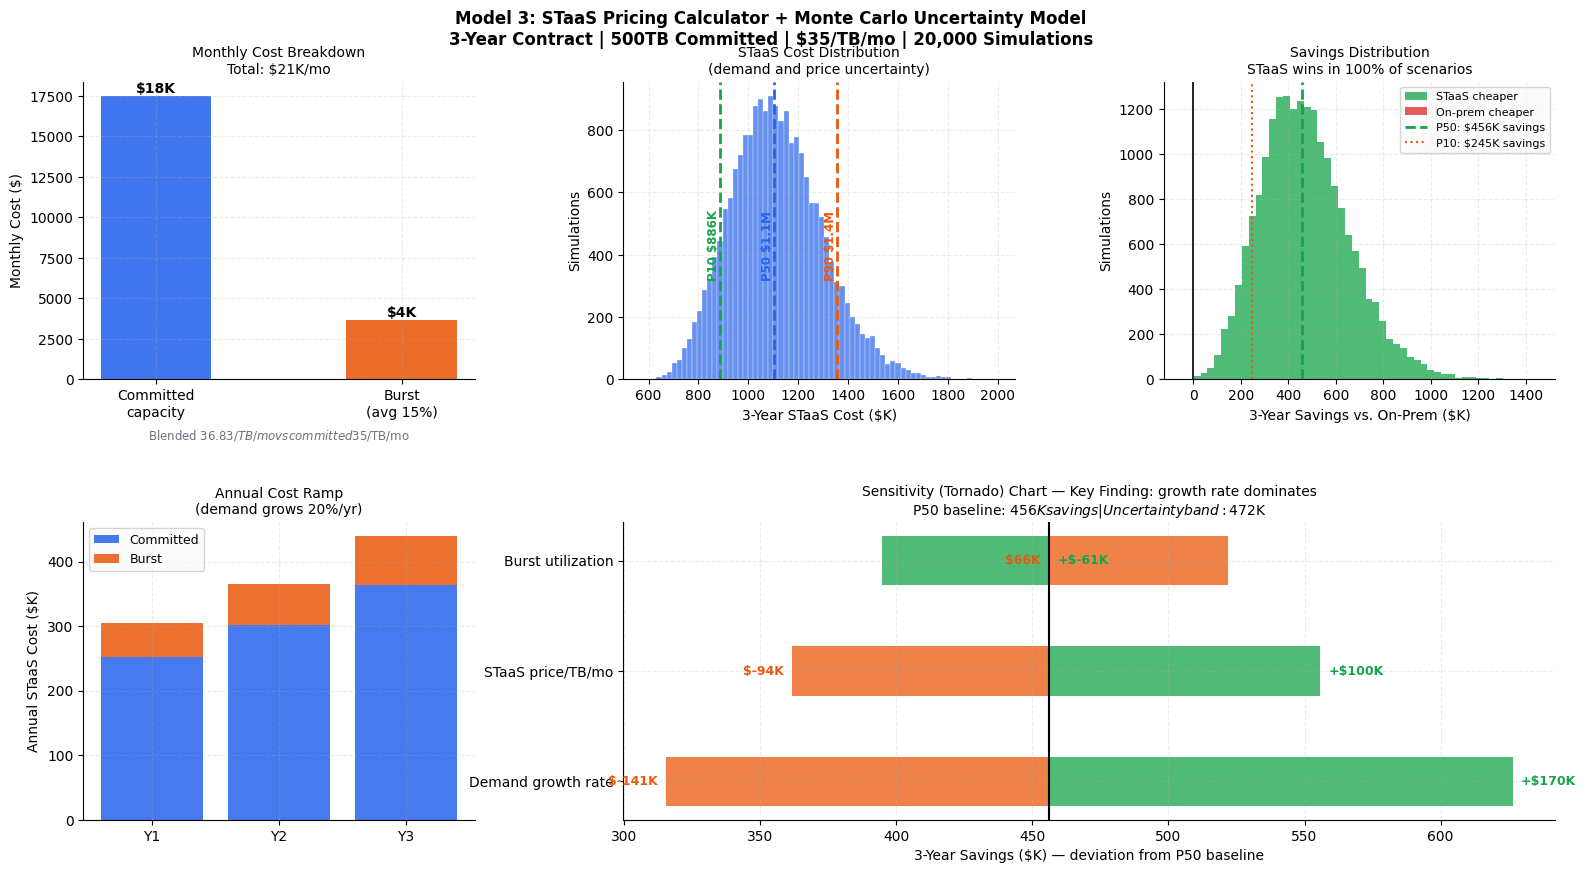

Model 3 complete.


In [11]:
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('white')
fig.suptitle('Model 3: STaaS Pricing Calculator + Monte Carlo Uncertainty Model\n'
             f'3-Year Contract | {COMMITTED_TB}TB Committed | ${KS_RATE}/TB/mo | {N3:,} Simulations',
             fontsize=12, fontweight='bold')

gs = gridspec.GridSpec(2, 3, hspace=0.48, wspace=0.38,
                       left=0.07, right=0.99, top=0.90, bottom=0.08)

# Panel A: Monthly pricing breakdown
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('white')
bars = ax1.bar(['Committed\ncapacity', 'Burst\n(avg 15%)'],
               [comm_mo, burst_mo], color=[BLUE, ORANGE], width=0.45, alpha=0.88)
for bar, v in zip(bars, [comm_mo, burst_mo]):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 200,
             fmt_k(v), ha='center', fontsize=10, fontweight='bold')
ax1.set_ylabel('Monthly Cost ($)')
ax1.set_title(f'Monthly Cost Breakdown\nTotal: {fmt_k(total_mo)}/mo', fontsize=10)
ax1.text(0.5, -0.20, f'Blended ${blended:.2f}/TB/mo  vs  committed ${KS_RATE}/TB/mo',
         transform=ax1.transAxes, ha='center', fontsize=8.5, color=GRAY)

# Panel B: STaaS cost distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('white')
ax2.hist(ks_3yr, bins=70, color=BLUE, alpha=0.70, edgecolor='white', lw=0.3)
yl = ax2.get_ylim()[1]
for val, pct_lbl, col in [(p10_ks, 'P10', GREEN), (p50_ks, 'P50', BLUE), (p90_ks, 'P90', ORANGE)]:
    ax2.axvline(val, color=col, lw=2, linestyle='--')
    ax2.text(val, yl*0.45, f'{pct_lbl} {fmt_k(val*1000)}', color=col, fontsize=8.5,
             fontweight='bold', rotation=90, va='center', ha='right')
ax2.set_xlabel('3-Year STaaS Cost ($K)')
ax2.set_ylabel('Simulations')
ax2.set_title('STaaS Cost Distribution\n(demand and price uncertainty)', fontsize=10)

# Panel C: Savings distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('white')
ax3.hist(savings[savings > 0],  bins=50, color=GREEN,    alpha=0.75, label='STaaS cheaper')
ax3.hist(savings[savings <= 0], bins=20, color='#DC2626', alpha=0.75, label='On-prem cheaper')
ax3.axvline(p50_sv, color=GREEN,  lw=2,   linestyle='--', label=f'P50: {fmt_k(p50_sv*1000)} savings')
ax3.axvline(p10_sv, color=ORANGE, lw=1.5, linestyle=':',  label=f'P10: {fmt_k(p10_sv*1000)} savings')
ax3.axvline(0, color='black', lw=1.2)
ax3.set_xlabel('3-Year Savings vs. On-Prem ($K)')
ax3.set_ylabel('Simulations')
ax3.set_title(f'Savings Distribution\nSTaaS wins in {prob:.0f}% of scenarios', fontsize=10)
ax3.legend(fontsize=8)

# Panel D: Annual cost ramp (deterministic)
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('white')
yr_lbl3 = [f'Y{y}' for y in range(1, CONTRACT_YRS + 1)]
yr_comm = [COMMITTED_TB * (1+GROWTH_MEAN)**y * KS_RATE * 12 / 1_000 for y in range(1, CONTRACT_YRS+1)]
yr_bst  = [COMMITTED_TB * (1+GROWTH_MEAN)**y * BURST_PCT3 * KS_RATE * (1+BURST_PREM3) * 12 / 1_000
           for y in range(1, CONTRACT_YRS+1)]
ax4.bar(yr_lbl3, yr_comm, color=BLUE,   alpha=0.85, label='Committed')
ax4.bar(yr_lbl3, yr_bst,  bottom=yr_comm, color=ORANGE, alpha=0.85, label='Burst')
ax4.set_ylabel('Annual STaaS Cost ($K)')
ax4.set_title('Annual Cost Ramp\n(demand grows 20%/yr)', fontsize=10)
ax4.legend(fontsize=9)

# Panel E: Tornado chart
ax5 = fig.add_subplot(gs[1, 1:])
ax5.set_facecolor('white')
base_sv = p50_sv
sens_sorted = sorted(sens, key=lambda x: abs(x[2]-x[1]), reverse=True)
yp = np.arange(len(sens_sorted))
for i, (name, low, high) in enumerate(sens_sorted):
    ax5.barh(i, high - base_sv, left=base_sv, color=GREEN,  alpha=0.75, height=0.45)
    ax5.barh(i, low  - base_sv, left=base_sv, color=ORANGE, alpha=0.75, height=0.45)
    ax5.text(max(high, base_sv) + 3, i, f'+{fmt_k((high-base_sv)*1000)}',
             va='center', fontsize=9, color=GREEN, fontweight='bold')
    ax5.text(min(low, base_sv) - 3, i, f'{fmt_k((low-base_sv)*1000)}',
             va='center', fontsize=9, color=ORANGE, fontweight='bold', ha='right')
ax5.set_yticks(yp)
ax5.set_yticklabels([s[0] for s in sens_sorted], fontsize=10)
ax5.axvline(base_sv, color='black', lw=1.5)
ax5.set_xlabel('3-Year Savings ($K) — deviation from P50 baseline')
ax5.set_title(f'Sensitivity (Tornado) Chart — Key Finding: growth rate dominates\n'
              f'P50 baseline: {fmt_k(p50_sv*1000)} savings  |  '
              f'Uncertainty band: {fmt_k((p90_sv-p10_sv)*1000)}',
              fontsize=10)

plt.savefig('model3_consumption_pricing.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Model 3 complete.')